# DEFINIÇÕES E CONSTANTES

In [2]:
# ---------- Paths ----------
PASTA_GERAL = "Dados/"
PASTA_DADOS = PASTA_GERAL + "Arquivos/"
SETUP_TESTES_XLSX = "Testes.xlsx"
NOME_ARQUIVO_LOG = "TEST_X.CSV"

# ---------- Pré-Processamento ----------
TEMPO_LIMPEZA_INICIAL = 5  # segundos
TIMESTAMP_PARA_SEGUNDOS = 1e3  # converter timestamp para segundos
NOME_VARIAVEL_TEMPO = "Timestamp"

# ---------- Estados ----------
niveis_estados = {
    0: "Balanceado",
    1: "Desbalanceado"
}

# HELPERS

In [3]:
def descritiva(df_, var, vresp='survived', max_classes=5):
    """
    Gera um gráfico descritivo da taxa de sobreviventes por categoria da variável especificada.
    
    Parâmetros:
    df : DataFrame - Base de dados a ser analisada.
    var : str - Nome da variável categórica a ser analisada.
    """
    
    df = df_.copy()
    
    if df[var].nunique()>max_classes:
        df[var] = pd.qcut(df[var], max_classes, duplicates='drop')
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    sns.pointplot(data=df, y=vresp, x=var, ax=ax1)
    
    # Criar o segundo eixo y para a taxa de sobreviventes
    ax2 = ax1.twinx()
    sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)
    ax2.set_ylabel('Frequência', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    ax1.set_zorder(2)
    ax1.patch.set_visible(False)  # Tornar o fundo do eixo 1 transparente
    
    # Exibir o gráfico
    plt.show()
    
def relatorio_missing(df):
    print(f'Número de linhas: {df.shape[0]} | Número de colunas: {df.shape[1]}')
    return pd.DataFrame({'Pct_missing': df.isna().mean().apply(lambda x: f"{x:.1%}"),
                          'Freq_missing': df.isna().sum().apply(lambda x: f"{x:,.0f}").replace(',','.')})
    

# Importações de Biblioteca

In [4]:
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import lightgbm as lgb
import shap
import joblib 

# from helpers import descritiva

c:\Users\Lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carregar Arquivos

## Carregar Testes.xlsx

In [7]:
# ---------- 1) Ler metadados do Excel ----------
df_meta = pd.read_excel(os.path.join(PASTA_GERAL, "Testes.xlsx"))

# Normaliza nomes de colunas (caso venham com espaços/variações)
df_meta = df_meta.rename(columns={
    "ID TEST": "ID_TEST",
})

# Garante tipos
df_meta["ID_TEST"] = df_meta["ID_TEST"].astype(int)

# Cria um dicionário: id -> (vel, desb)
meta_map = (
    df_meta
    .set_index("ID_TEST")[["Velocity", "Imbalance"]]
    .to_dict(orient="index")
)



## Carregar os Dados

In [8]:
dados_original_separados = []  # Lista para armazenar os dados lidos
dados_original_juntos = []     # Lista para armazenar os dados combinados

# ---------- 1) Definindo local do arquivo ----------
padrao = re.compile(NOME_ARQUIVO_LOG.replace("X", r"(\d+)"), re.IGNORECASE)

# ---------- 2) Lendo arquivos CSV ----------
for nome_arquivo in os.listdir(PASTA_DADOS):
    correspondencia = padrao.match(nome_arquivo)
    if correspondencia:
        id_teste = int(correspondencia.group(1))
        caminho_arquivo = os.path.join(PASTA_DADOS, nome_arquivo)
        
        # Lê o arquivo CSV
        df_dados = pd.read_csv(caminho_arquivo)
        
        # Adiciona colunas de metadados
        if id_teste in meta_map:
            df_dados["Velocity"] = meta_map[id_teste]["Velocity"]
            df_dados["Imbalance"] = meta_map[id_teste]["Imbalance"]
            df_dados["ID_TEST"] = id_teste
            
            dados_original_separados.append(df_dados)
            
            print(f"Lido arquivo: {nome_arquivo} com ID_TEST {id_teste}")
        else:
            print(f"Metadados não encontrados para ID_TEST {id_teste}")
            
# ---------- 3) Junta tudo em um único DataFrame ----------
dados_original_juntos = pd.concat(dados_original_separados, ignore_index=True)

Lido arquivo: TEST_1.csv com ID_TEST 1
Lido arquivo: TEST_10.csv com ID_TEST 10
Lido arquivo: TEST_11.csv com ID_TEST 11
Lido arquivo: TEST_12.csv com ID_TEST 12
Lido arquivo: TEST_13.csv com ID_TEST 13
Lido arquivo: TEST_14.csv com ID_TEST 14
Lido arquivo: TEST_15.csv com ID_TEST 15
Lido arquivo: TEST_16.csv com ID_TEST 16
Lido arquivo: TEST_17.csv com ID_TEST 17
Lido arquivo: TEST_18.csv com ID_TEST 18
Lido arquivo: TEST_19.csv com ID_TEST 19
Lido arquivo: TEST_2.csv com ID_TEST 2
Lido arquivo: TEST_20.csv com ID_TEST 20
Lido arquivo: TEST_21.csv com ID_TEST 21
Lido arquivo: TEST_22.csv com ID_TEST 22
Lido arquivo: TEST_23.csv com ID_TEST 23
Lido arquivo: TEST_24.csv com ID_TEST 24
Lido arquivo: TEST_25.csv com ID_TEST 25
Lido arquivo: TEST_26.csv com ID_TEST 26
Lido arquivo: TEST_27.csv com ID_TEST 27
Lido arquivo: TEST_28.csv com ID_TEST 28
Lido arquivo: TEST_29.csv com ID_TEST 29
Lido arquivo: TEST_3.csv com ID_TEST 3
Lido arquivo: TEST_30.csv com ID_TEST 30
Lido arquivo: TEST_31.

### Checagem rápida dos dados

In [9]:
print(dados_original_juntos.head())
print(dados_original_juntos.columns)

   Timestamp  Accel_X  Accel_Y  Accel_Z  Gyro_X  Gyro_Y  Gyro_Z  Mag_X  Mag_Y  \
0          0      -48       36      996       0       0       0    214   -366   
1         10      -46       25     1005       0       0       0    213   -372   
2         20      -73       70      979       0       0       0    210   -372   
3         30      -56       56      988       0       0       0    213   -361   
4         40      -54       26      996       0       0       0    205   -366   

   Mag_Z  Velocity  Imbalance  ID_TEST  
0   -942         0          0        1  
1   -951         0          0        1  
2   -952         0          0        1  
3   -939         0          0        1  
4   -957         0          0        1  
Index(['Timestamp', 'Accel_X', 'Accel_Y', 'Accel_Z', 'Gyro_X', 'Gyro_Y',
       'Gyro_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Velocity', 'Imbalance',
       'ID_TEST'],
      dtype='object')


# Pre Processing

## Limpeza inicial dos dados
Limpa os primeiros segundos de cada arquivo para não ter nenhum resquício de ruido, ou seja, em velocidade não ter ruido de movimento em parado ou aceleração.
 

In [10]:
# Limpar os primeiros segundos de cada teste carregado
for id_teste in dados_original_juntos["ID_TEST"].unique():
    filtro_teste = dados_original_juntos["ID_TEST"] == id_teste
    limite_tempo = (TEMPO_LIMPEZA_INICIAL) * TIMESTAMP_PARA_SEGUNDOS
    
    dados_original_juntos = dados_original_juntos[~(filtro_teste & (dados_original_juntos[NOME_VARIAVEL_TEMPO] < limite_tempo))]



## Remoção de colunas que não são utilizadas

In [11]:
dados_filtados = dados_original_juntos.copy()

# remover coluna timestamp
dados_filtados = dados_filtados.drop(columns=[NOME_VARIAVEL_TEMPO, "Velocity", "ID_TEST"])



## Imbalance onde for diferente de 0 ou 1, colocar 1 pois coluna apenas descreve se esta desbalanceado ou não

In [12]:
# Onde imbalance é diferente de 0 ou 1, colocar como 1
dados_filtados['Imbalance'] = dados_filtados['Imbalance'].apply(lambda x: 1 if x not in [0, 1] else x)

# Análise Geral

## Verifica possíveis missing

In [25]:
relatorio_missing(dados_original_juntos)
relatorio_missing(dados_filtados)

Número de linhas: 135000 | Número de colunas: 13
Número de linhas: 135000 | Número de colunas: 10


,Pct_missing,Freq_missing
Accel_X,0.0%,0
Accel_Y,0.0%,0
Accel_Z,0.0%,0
Gyro_X,0.0%,0
Gyro_Y,0.0%,0
Gyro_Z,0.0%,0
Mag_X,0.0%,0
Mag_Y,0.0%,0
Mag_Z,0.0%,0
Imbalance,0.0%,0


## Verifica os tipos

In [ ]:
metadados = dados_original_juntos.dtypes
print(metadados)

## Análise descritiva



Análise univariada de Accel_X:
count    135000.000000
mean        112.471956
std         191.508575
min       -1208.000000
25%         -34.000000
50%          82.000000
75%         213.000000
max        1998.000000
Name: Accel_X, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


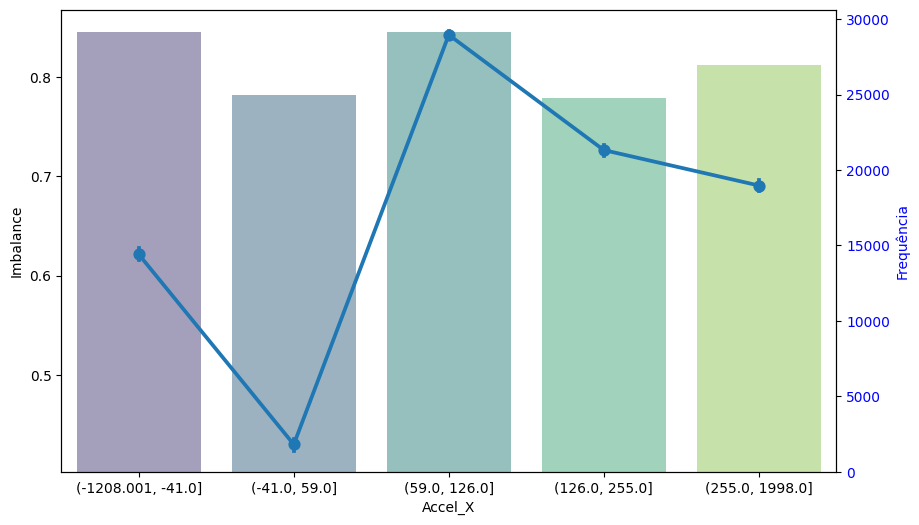



Análise univariada de Accel_Y:
count    135000.000000
mean        -78.004770
std         385.176345
min       -1998.000000
25%        -204.000000
50%         -16.000000
75%          68.000000
max        1998.000000
Name: Accel_Y, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


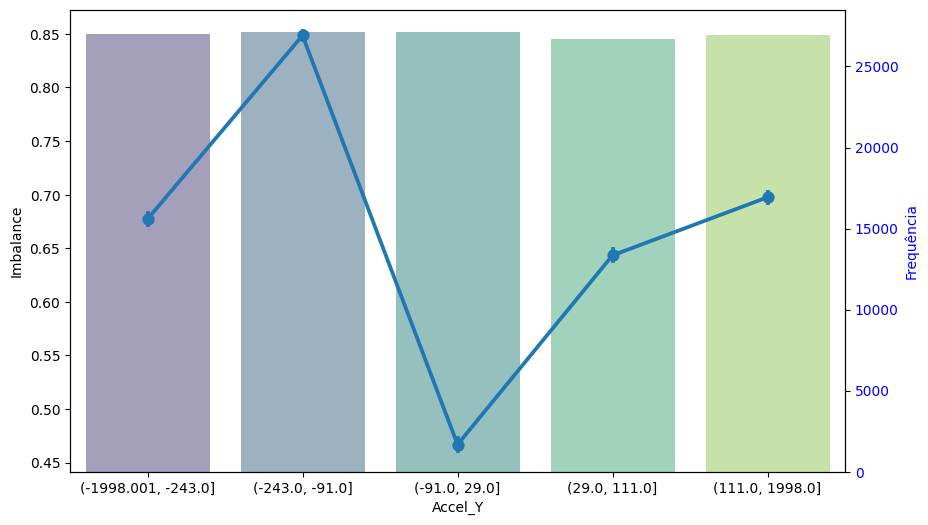



Análise univariada de Accel_Z:
count    135000.000000
mean        995.323400
std         166.065945
min       -1602.000000
25%         952.000000
50%         997.000000
75%        1032.000000
max        1998.000000
Name: Accel_Z, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


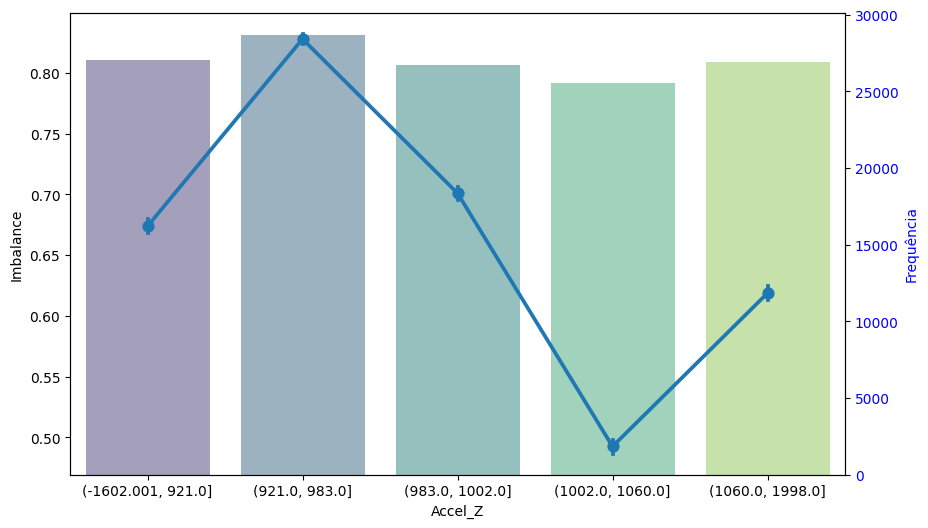



Análise univariada de Gyro_X:
count    135000.000000
mean         -1.777415
std           3.462066
min         -45.000000
25%          -3.000000
50%          -1.000000
75%           0.000000
max          29.000000
Name: Gyro_X, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


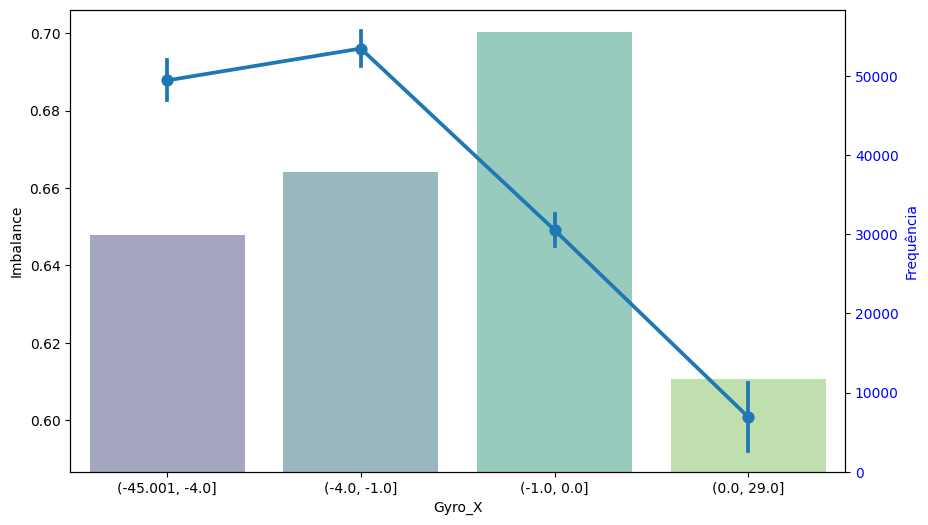



Análise univariada de Gyro_Y:
count    135000.000000
mean         -0.790970
std           4.739893
min         -38.000000
25%          -2.000000
50%           0.000000
75%           0.000000
max          23.000000
Name: Gyro_Y, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


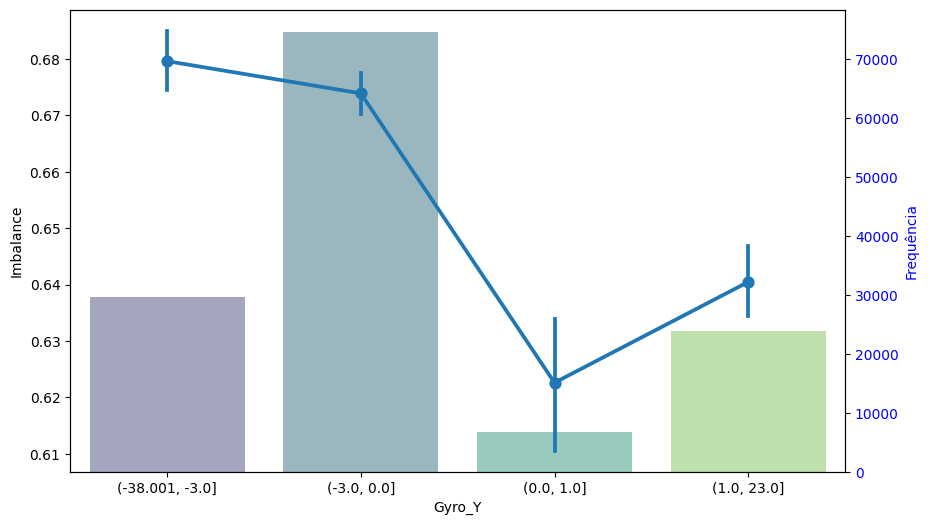



Análise univariada de Gyro_Z:
count    135000.000000
mean        223.867822
std         198.424871
min          -4.000000
25%          53.000000
50%         175.000000
75%         363.000000
max         611.000000
Name: Gyro_Z, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


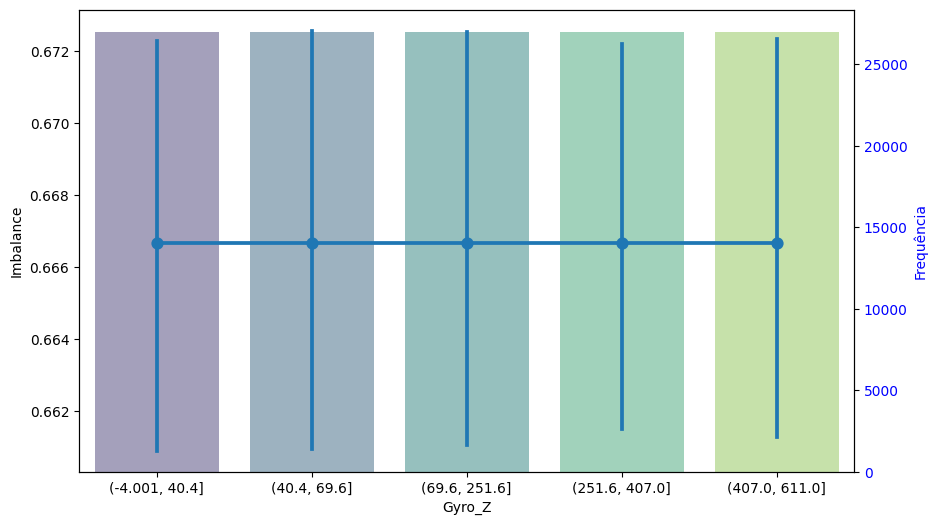



Análise univariada de Mag_X:
count    135000.000000
mean        118.269156
std         384.169073
min        -891.000000
25%        -159.000000
50%         189.000000
75%         390.000000
max         850.000000
Name: Mag_X, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


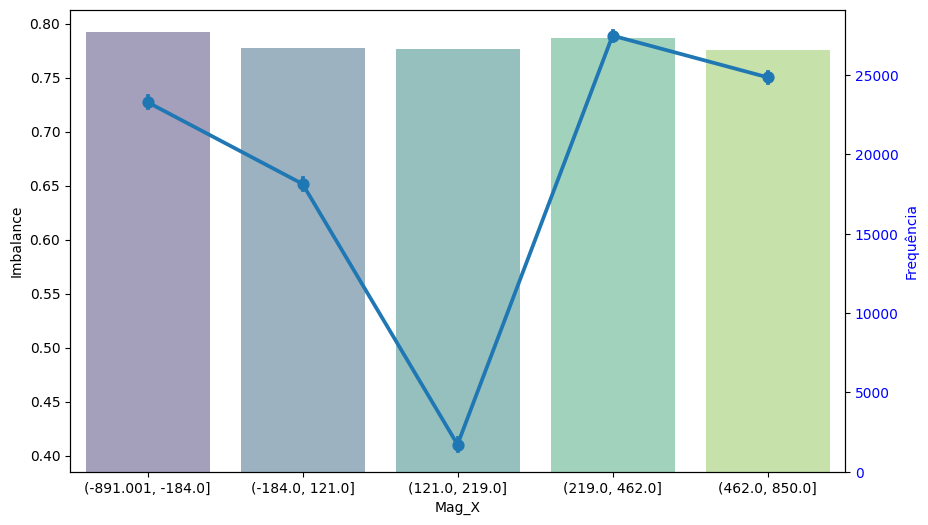



Análise univariada de Mag_Y:
count    135000.00000
mean       -167.38743
std         368.09767
min        -675.00000
25%        -396.00000
50%        -330.00000
75%          18.00000
max         745.00000
Name: Mag_Y, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


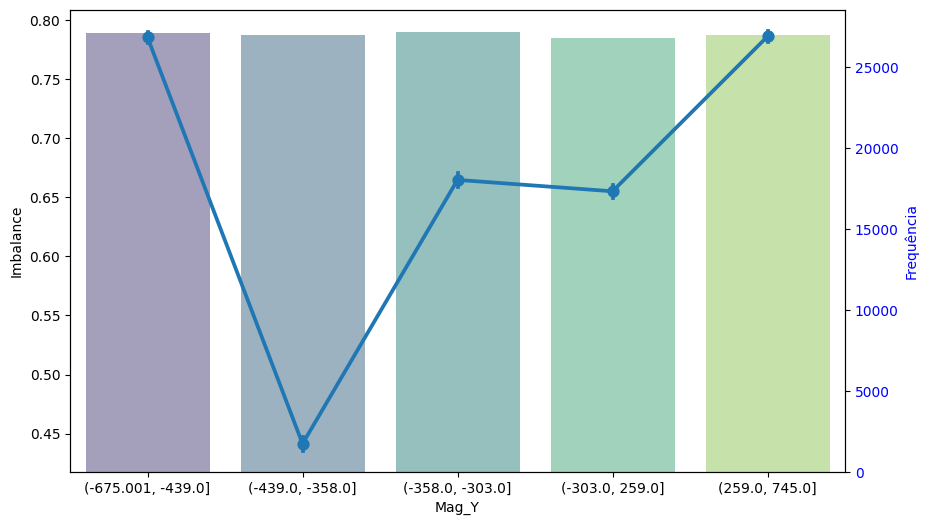



Análise univariada de Mag_Z:
count    135000.000000
mean       -995.938881
std         255.834210
min       -1633.000000
25%       -1134.000000
50%        -921.000000
75%        -843.000000
max        -642.000000
Name: Mag_Z, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


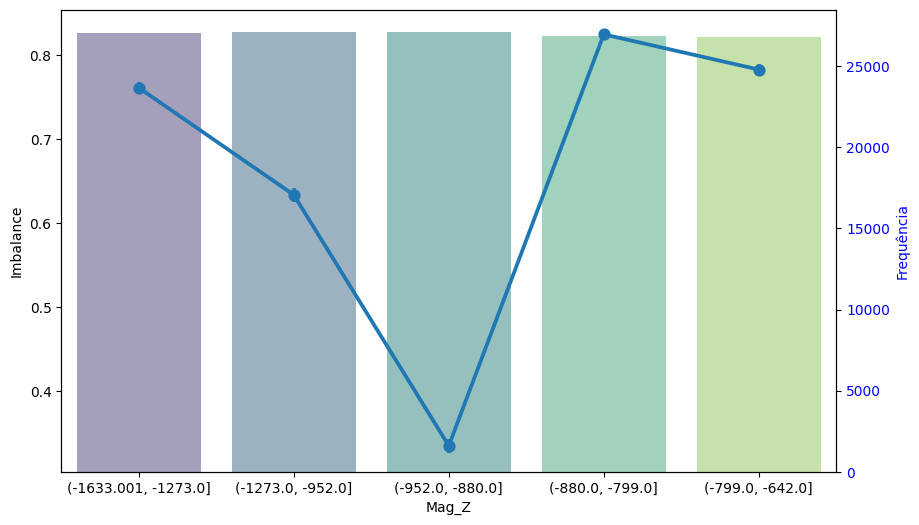



Análise univariada de Imbalance:
count    135000.000000
mean          0.666667
std           0.471406
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: Imbalance, dtype: float64


C:\Users\Lucas\AppData\Local\Temp\ipykernel_5652\2787088267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis', alpha=0.5, ax=ax2)


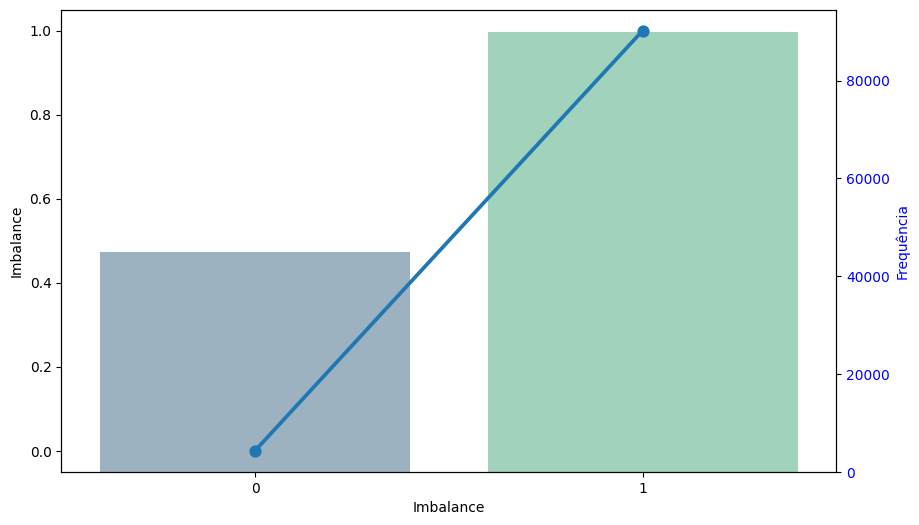

In [26]:
# Análise descritiva básica

for variavel in dados_filtados.columns:
    print(f'\n\nAnálise univariada de {variavel}:')
    print(dados_filtados[variavel].describe())
    
    descritiva(dados_filtados, variavel, vresp='Imbalance', max_classes=5)

# Árvores de decisão

## Separação das variáveis

In [14]:
y= dados_filtados['Imbalance']
X= dados_filtados.drop(columns=['Imbalance'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2208)

# Imprima as formas dos conjuntos de dados resultantes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print(y_test.value_counts())



X_train shape: (108000, 9)
y_train shape: (108000,)
X_test shape: (27000, 9)
y_test shape: (27000,)
Imbalance
1    17969
0     9031
Name: count, dtype: int64


## LightGBM

### Configuração LightGBM

In [22]:
# Treinamento do modelo LightGBM com otimização Bayesiana de hiperparâmetros
param_space = {
    'n_estimators': Integer(50, 500), #Número de árvores
    'max_depth': Integer(3, 15), #Profundidade máxima da árvore
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'), #Taxa de aprendizado
    'num_leaves': Integer(20, 150), #Número de folhas
    'min_child_samples': Integer(5, 100), #Número mínimo de amostras em uma folha
    'subsample': Real(0.5, 1.0), #Subamostragem de dados
    'colsample_bytree': Real(0.5, 1.0), #Subamostragem de colunas(features)
    'reg_alpha': Real(1e-9, 10.0, prior='log-uniform'), #Regularização L1
    'reg_lambda': Real(1e-9, 10.0, prior='log-uniform'), #Regularização L2
    'boosting_type': Categorical(['gbdt', 'dart', 'goss']) #Tipo de boosting
}

#Configurar o modelo LightGBM
lgb_model = lgb.LGBMClassifier(random_state=2208, verbose=-1)

# Configurar o Bayesian Optimization
bayes_search = BayesSearchCV(
    estimator=lgb_model,
    search_spaces=param_space,
    n_iter=32,  # Número de iterações de otimização
    cv=3,  # Validação cruzada com 3 folds
    scoring='accuracy',  # Métrica de avaliação
    n_jobs=-1,  # Usar todos os núcleos disponíveis
    verbose=1,
    random_state=2208
)

### Execução Árvore

In [23]:
# Execução do Bayesian Optimization
tempo_ini = pd.Timestamp.now() # Início do tempo
bayes_search.fit(X_train, y_train)
tempo_fim = pd.Timestamp.now() # Fim do tempo
print(f'Tempo de execução do Bayesian Optimization: {tempo_fim - tempo_ini}')

# Avaliação do modelo otimizado
print("Melhores hiperparâmetros encontrados:")
print(bayes_search.best_params_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

### Carregar Árvore

In [18]:
import joblib

# Carregar o estimator salvo (já treinado)
bayes_search_loaded = joblib.load('LightGBM_best_estimator.pkl')

### Previsões

In [12]:
# verificar se bayes_search e bayes_search_loaded existem
if 'bayes_search' in locals():
    pred = bayes_search.predict(X_test)
    print("Usando bayes_search para previsões.")
elif 'bayes_search_loaded' in locals():
    pred = bayes_search_loaded.predict(X_test)
    print("Usando bayes_search_loaded para previsões.")
else:  
    raise ValueError("Nenhum modelo disponível para fazer previsões.")

Usando bayes_search_loaded para previsões.


### Estatísticas da árvore gerada

In [14]:
# Matriz de confusão e estatísticas de classificação
cm = confusion_matrix(y_test, pred)
print("Matriz de Confusão:")
print(cm)
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred))
print(f'Accuracy: {accuracy_score(y_test, pred):.2%}')


Matriz de Confusão:
[[ 8979    52]
 [   18 17951]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9031
           1       1.00      1.00      1.00     17969

    accuracy                           1.00     27000
   macro avg       1.00      1.00      1.00     27000
weighted avg       1.00      1.00      1.00     27000

Accuracy: 99.74%


In [15]:
# Função personalizada para summary (multiClassSummary equivalente)
def multiCLassSummary(df, levels):
    report = classification_report(df['obs'], df['pred'], target_names=levels, output_dict=True)
    summary = { 
               'Accuracy': report['accuracy'],
    }
    for level in levels:
        summary[f'{level} Precision'] = report[level]['precision']
        summary[f'{level} Recall'] = report[level]['recall']
        summary[f'{level} F1-Score'] = report[level]['f1-score']
    return summary
# Gerar um DataFrame temporário para avaliar o modelo
lgb_aval = pd.DataFrame({
    'pred': pred,
    'obs': y_test
})

# Calcular e exibir o resumo personalizado
print(niveis_estados.values()   )
metrics_summary = pd.Series(multiCLassSummary(lgb_aval,niveis_estados.values()))
print("\nMétricas de Avaliação Personalizadas:")
print(metrics_summary)


dict_values(['Balanceado', 'Desbalanceado'])

Métricas de Avaliação Personalizadas:
Accuracy                   0.997407
Balanceado Precision       0.997999
Balanceado Recall          0.994242
Balanceado F1-Score        0.996117
Desbalanceado Precision    0.997112
Desbalanceado Recall       0.998998
Desbalanceado F1-Score     0.998054
dtype: float64


### Análise Shap

c:\Users\Lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


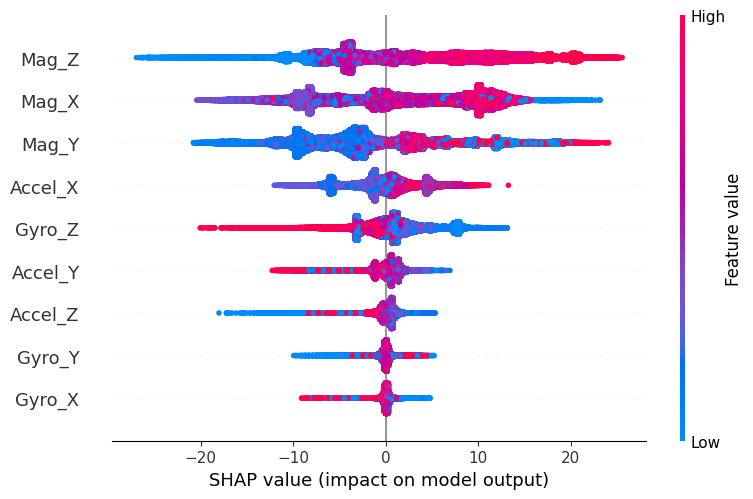

In [29]:
model = bayes_search.best_estimator_
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X) 

### Execução Árvore sem algumas variáveis

In [ ]:
# Execução da arvore sem algumas variáveis
removed_cols = ['Accel_Z', 'Accel_Y', 'Gyro_X','Gyro_Y']

X_removed_cols = dados_filtados.drop(columns=['Imbalance'] + removed_cols)
X_train_removed_cols, X_test_removed_cols, y_train_removed_cols, y_test_removed_cols = train_test_split(X_removed_cols, y, test_size=0.2, random_state=2208)

# Execução do Bayesian Optimization
tempo_ini = pd.Timestamp.now() # Início do tempo
bayes_search_with_removed_cols = bayes_search
bayes_search_with_removed_cols.fit(X_train_removed_cols, y_train_removed_cols)
tempo_fim = pd.Timestamp.now() # Fim do tempo
print(f'Tempo de execução do Bayesian Optimization: {tempo_fim - tempo_ini}')

# Avaliação do modelo otimizado
print("Melhores hiperparâmetros encontrados:")
print(bayes_search_with_removed_cols.best_params_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

c:\Users\Lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gbdt'), 1.0, 0.29999999999999993, np.int64(15), np.int64(5), np.int64(500), np.int64(150), 1e-09, 1e-09, 0.5] before, using random point ['dart', 0.6914296215737197, 0.12711729113407577, np.int64(12), np.int64(52), np.int64(390), np.int64(133), 0.0017359575437671912, 0.6725691867663594, 0.967030836822766]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Tempo de execução do Bayesian Optimization: 0 days 00:04:11.644255
Melhores hiperparâmetros encontrados:
OrderedDict({'boosting_type': 'gbdt', 'colsample_bytree': 1.0, 'learning_rate': 0.29999999999999993, 'max_depth': 15, 'min_child_samples': 5, 'n_estimators': 500, 'num_leaves': 150, 'reg_alpha': 1e-09, 'reg_lambda': 1e-09, 'subsample': 0.5})


In [ ]:
pred_with_removed_cols = bayes_search_with_removed_cols.predict(X_test_removed_cols)
print(X_removed_cols.columns)

# Matriz de confusão e estatísticas de classificação
cm = confusion_matrix(y_test_removed_cols, pred_with_removed_cols)
print("Matriz de Confusão:")
print(cm)
print("\nRelatório de Classificação:")
print(classification_report(y_test_removed_cols, pred_with_removed_cols))
print(f'Accuracy: {accuracy_score(y_test_removed_cols, pred_with_removed_cols):.2%}')

Index(['Accel_X', 'Gyro_Z', 'Mag_X', 'Mag_Y', 'Mag_Z'], dtype='object')
Matriz de Confusão:
[[ 8924   107]
 [   46 17923]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9031
           1       0.99      1.00      1.00     17969

    accuracy                           0.99     27000
   macro avg       0.99      0.99      0.99     27000
weighted avg       0.99      0.99      0.99     27000

Accuracy: 99.43%


### Execução Árvore só com x

In [36]:
# Execução da arvore sem algumas variáveis deixando apenas Accel_X
removed_cols = dados_filtados.columns.difference(['Accel_X']).tolist()

X_removed_cols_2 = dados_filtados.drop(columns=['Imbalance'] + removed_cols)
X_train_removed_cols_2, X_test_removed_cols_2, y_train_removed_cols_2, y_test_removed_cols_2 = train_test_split(X_removed_cols_2, y, test_size=0.2, random_state=2208)

# Execução do Bayesian Optimization
tempo_ini = pd.Timestamp.now() # Início do tempo
bayes_search_with_removed_cols_2 = bayes_search
bayes_search_with_removed_cols_2.fit(X_train_removed_cols_2, y_train_removed_cols_2)
tempo_fim = pd.Timestamp.now() # Fim do tempo
print(f'Tempo de execução do Bayesian Optimization: {tempo_fim - tempo_ini}')

# Avaliação do modelo otimizado
print("Melhores hiperparâmetros encontrados:")
print(bayes_search_with_removed_cols_2.best_params_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

In [37]:
pred_with_removed_cols_2 = bayes_search_with_removed_cols_2.predict(X_test_removed_cols_2)
print(X_removed_cols_2.columns)

# Matriz de confusão e estatísticas de classificação
cm = confusion_matrix(y_test_removed_cols_2, pred_with_removed_cols_2)
print("Matriz de Confusão:")
print(cm)
print("\nRelatório de Classificação:")
print(classification_report(y_test_removed_cols_2, pred_with_removed_cols_2))
print(f'Accuracy: {accuracy_score(y_test_removed_cols_2, pred_with_removed_cols_2):.2%}')

Index(['Accel_X'], dtype='object')
Matriz de Confusão:
[[ 3660  5371]
 [ 1741 16228]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.68      0.41      0.51      9031
           1       0.75      0.90      0.82     17969

    accuracy                           0.74     27000
   macro avg       0.71      0.65      0.66     27000
weighted avg       0.73      0.74      0.72     27000

Accuracy: 73.66%


## Salvar Árvore

In [ ]:
# Salvar o estimator otimizado (pickle)
joblib.dump(bayes_search.best_estimator_, 'LightGBM_best_estimator.pkl')

## Matriz de correlação

In [13]:
# Fazer a matriz de correlação dos dados filtrados
corr = dados_filtados.corr()
plt.figure(figsize=(12, 10), dpi=1024)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação dos Dados Filtrados', fontsize=16)
plt.tight_layout() # Ajusta o layout para evitar cortes de elementos
plt.tick_params(labelsize=10) # Ajusta o tamanho dos rótulos dos eixos
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo x para melhor visualização
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_8704\2564225880.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


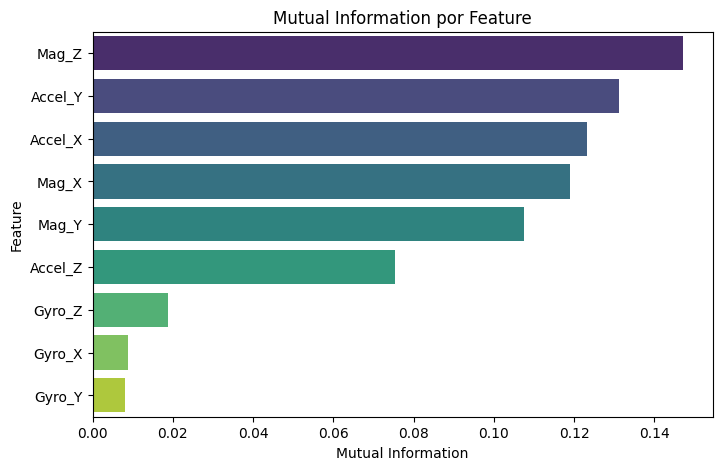

In [16]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)
import pandas as pd

mi = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": X.columns,
    "mutual_info": mi
}).sort_values("mutual_info", ascending=False)

mi_df


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    data=mi_df,
    x="mutual_info",
    y="feature",
    palette="viridis"
)
plt.title("Mutual Information por Feature")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()